import pandas as pd
df = pd.read_csv('../data/laptop_prices.csv')
print('Shape:', df.shape)
df.head()

# Laptop Price Analysis & Prediction

**Goal:** Build a regression model to predict laptop prices (in Euros) from hardware specs, and identify what drives the price.

**Dataset:** 1,275 laptops with 23 features (brand, RAM, CPU, GPU, storage, screen, etc.)

**Approach:**
1. Exploratory Data Analysis (EDA)
2. Feature engineering (PPI, encoding)
3. Train Linear Regression (baseline) + Random Forest (main model)
4. Compare with R², MAE, RMSE
5. Feature importance analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/laptop_prices.csv')
print('Shape:', df.shape)
df.head()

Shape: (1275, 23)


,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   str    
 1   Product               1275 non-null   str    
 2   TypeName              1275 non-null   str    
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   str    
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   str    
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   str    
 12  IPSpanel              1275 non-null   str    
 13  RetinaDisplay         1275 non-null   str    
 14  CPU_company           1275 non-null   str    
 15  CPU_freq              1275 non-n

In [4]:
print('Total missing values in dataset:', df.isnull().sum().sum())

Total missing values in dataset: 0


## 2. Exploratory Data Analysis

### 2.1 Target variable: Price

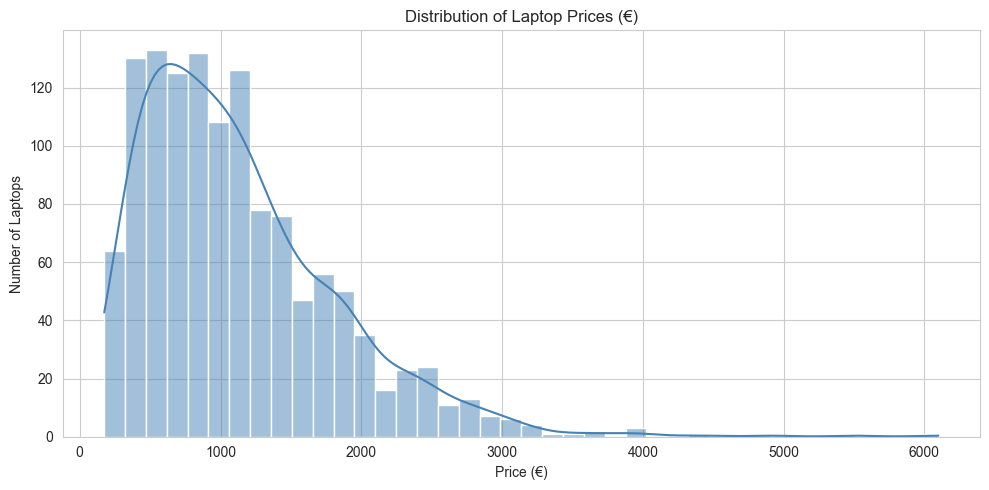

count    1275.00
mean     1134.97
std       700.75
min       174.00
25%       609.00
50%       989.00
75%      1496.50
max      6099.00
Name: Price_euros, dtype: float64


In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price_euros'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Laptop Prices (€)')
plt.xlabel('Price (€)')
plt.ylabel('Number of Laptops')
plt.tight_layout()
plt.show()

print(df['Price_euros'].describe().round(2))

### 2.2 Price by Brand

C:\Users\itzme\AppData\Local\Temp\ipykernel_12616\4226910015.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_price.index, y=brand_price['mean'], palette='viridis')


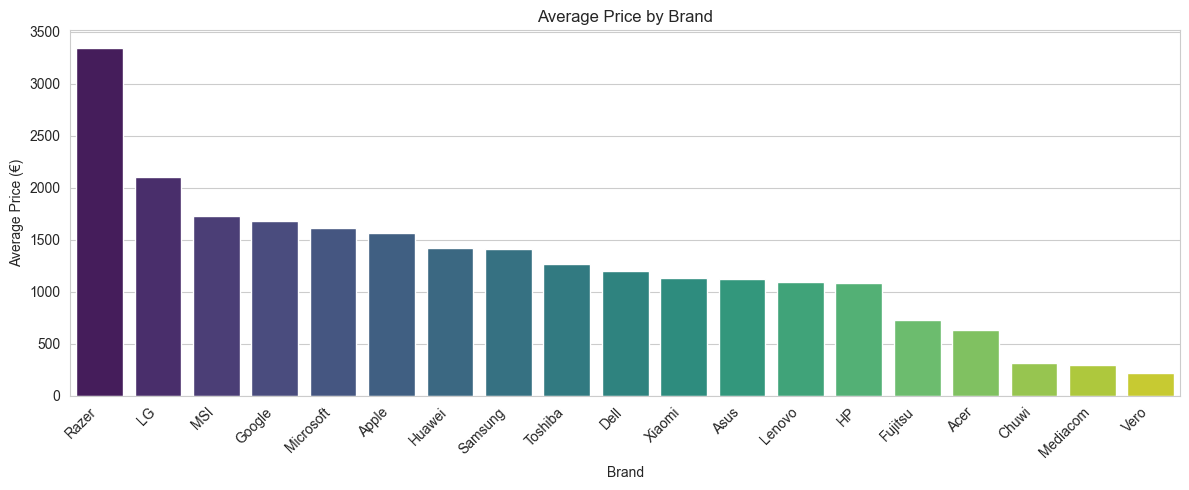

,mean,count
Company,,
Razer,3346.0,7
LG,2099.0,3
MSI,1729.0,54
Google,1678.0,3
Microsoft,1612.0,6
Apple,1564.0,21
Huawei,1424.0,2
Samsung,1413.0,9
Toshiba,1268.0,48


In [7]:
brand_price = df.groupby('Company')['Price_euros'].agg(['mean', 'count']).round(0).sort_values('mean', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=brand_price.index, y=brand_price['mean'], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Average Price by Brand')
plt.ylabel('Average Price (€)')
plt.xlabel('Brand')
plt.tight_layout()
plt.show()

brand_price

**Observation:** Razer, LG, MSI, Apple, and Microsoft are premium brands (€1500+). Mediacom, Vero, and Chuwi are budget brands. Brand will be an important feature for the model.

### 2.3 Price by Laptop Type

C:\Users\itzme\AppData\Local\Temp\ipykernel_12616\4272220229.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_price.index, y=type_price.values, palette='Set2')


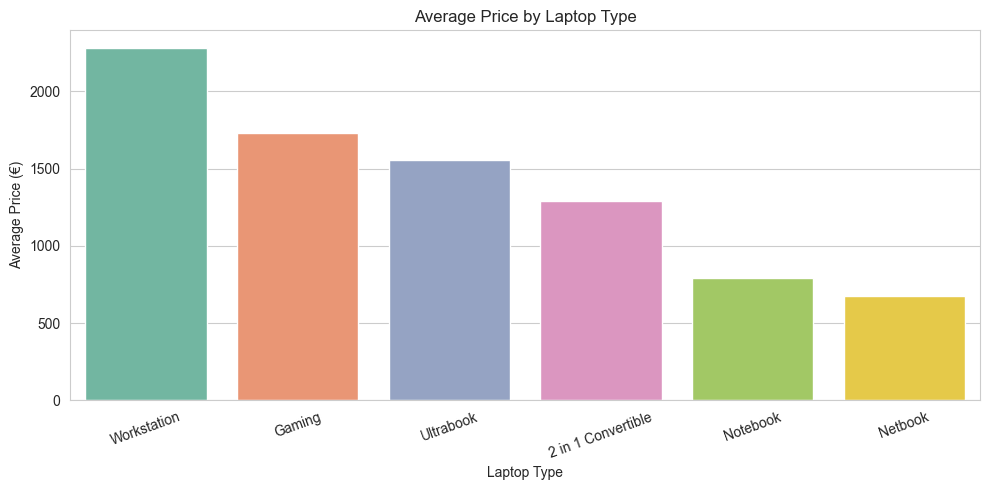

TypeName
Workstation           2280.0
Gaming                1731.0
Ultrabook             1557.0
2 in 1 Convertible    1290.0
Notebook               789.0
Netbook                673.0
Name: Price_euros, dtype: float64

In [8]:
type_price = df.groupby('TypeName')['Price_euros'].mean().round(0).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=type_price.index, y=type_price.values, palette='Set2')
plt.xticks(rotation=20)
plt.title('Average Price by Laptop Type')
plt.ylabel('Average Price (€)')
plt.xlabel('Laptop Type')
plt.tight_layout()
plt.show()

type_price

**Observation:** Workstations and Gaming laptops are the most expensive categories. Netbooks are the cheapest. Laptop type will also be a strong predictor.

### 2.4 RAM vs Price

C:\Users\itzme\AppData\Local\Temp\ipykernel_12616\2557945673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ram', y='Price_euros', palette='coolwarm')


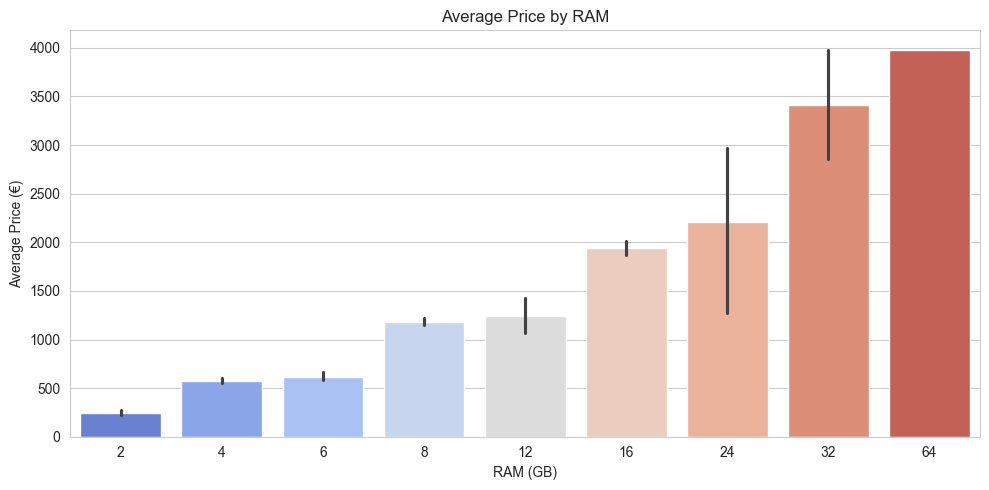

Correlation between RAM and Price: 0.74


In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Ram', y='Price_euros', palette='coolwarm')
plt.title('Average Price by RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Average Price (€)')
plt.tight_layout()
plt.show()

print('Correlation between RAM and Price:', round(df['Ram'].corr(df['Price_euros']), 3))

**Observation:** Strong positive relationship between RAM and price (correlation ~0.74). RAM will be one of the most important features.

### 2.5 Storage Type

C:\Users\itzme\AppData\Local\Temp\ipykernel_12616\2900519632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=storage_price.index, y=storage_price.values, palette='pastel')


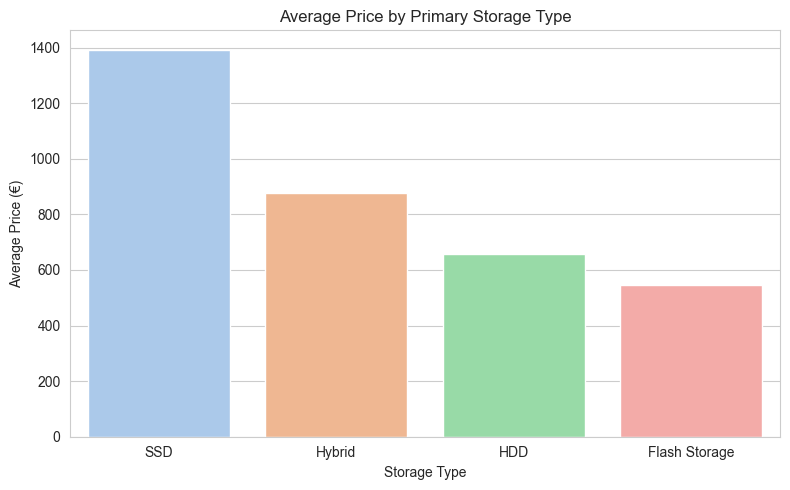

PrimaryStorageType
SSD              1392.0
Hybrid            876.0
HDD               658.0
Flash Storage     545.0
Name: Price_euros, dtype: float64

In [10]:
storage_price = df.groupby('PrimaryStorageType')['Price_euros'].mean().round(0).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=storage_price.index, y=storage_price.values, palette='pastel')
plt.title('Average Price by Primary Storage Type')
plt.xlabel('Storage Type')
plt.ylabel('Average Price (€)')
plt.tight_layout()
plt.show()

storage_price

**Observation:** SSD laptops cost noticeably more than HDD laptops. Storage type is an important price driver.

### 2.6 Feature Engineering — PPI (Pixels Per Inch)

Instead of using `ScreenW`, `ScreenH`, and `Inches` separately, we can combine them into a single feature called **PPI** (pixels per inch). This captures screen quality in one number.

**Formula:** `PPI = √(ScreenW² + ScreenH²) / Inches`

For example, a 13-inch laptop with 2560×1600 resolution has higher PPI (= better screen) than a 17-inch laptop with 1920×1080.

C:\Users\itzme\AppData\Local\Temp\ipykernel_12616\1094917182.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ppi_price.index, y=ppi_price.values, palette='Blues')


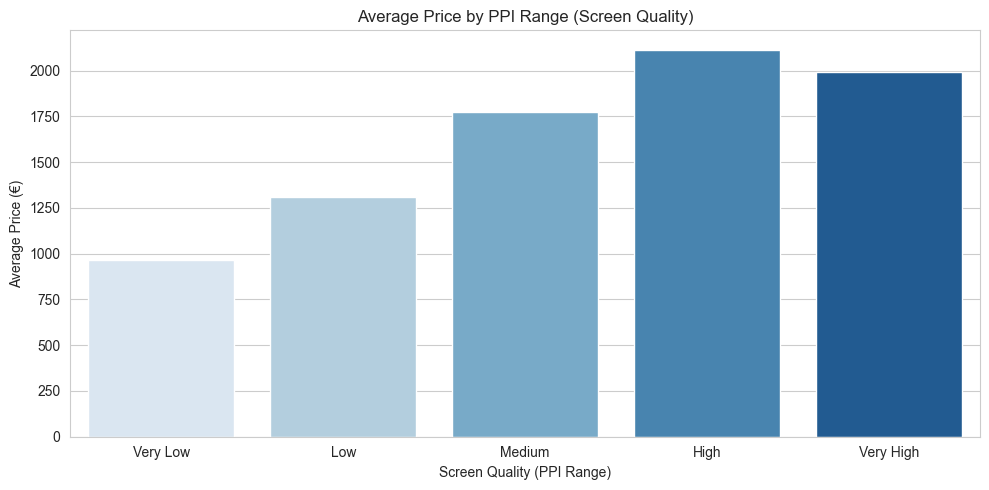

Correlation between PPI and Price: 0.47


In [12]:
# Create PPI feature
df['PPI'] = (np.sqrt(df['ScreenW']**2 + df['ScreenH']**2) / df['Inches']).round(2)

# Group laptops into PPI ranges and show average price
df['PPI_range'] = pd.cut(df['PPI'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
ppi_price = df.groupby('PPI_range', observed=True)['Price_euros'].mean().round(0)

plt.figure(figsize=(10, 5))
sns.barplot(x=ppi_price.index, y=ppi_price.values, palette='Blues')
plt.title('Average Price by PPI Range (Screen Quality)')
plt.xlabel('Screen Quality (PPI Range)')
plt.ylabel('Average Price (€)')
plt.tight_layout()
plt.show()

# Drop the helper column (we only needed it for the chart)
df = df.drop(columns=['PPI_range'])

print('Correlation between PPI and Price:', round(df['PPI'].corr(df['Price_euros']), 3))

### 2.7 Correlation Heatmap

This chart shows how strongly each numeric feature relates to every other feature (and to price). Values range from -1 to +1:
- **Close to +1** → strong positive relationship
- **Close to 0** → no relationship
- **Close to -1** → strong negative relationship

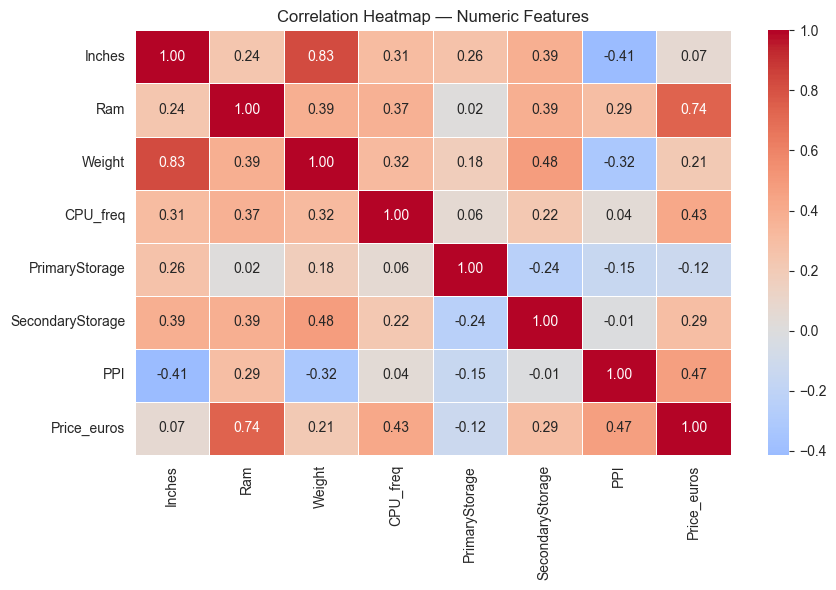

In [13]:
num_cols = ['Inches', 'Ram', 'Weight', 'CPU_freq', 'PrimaryStorage', 
            'SecondaryStorage', 'PPI', 'Price_euros']

plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', 
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

**Observation:** The strongest numeric predictors of price are:
1. **RAM (0.74)** — strongest single feature
2. **PPI (0.47)** — screen quality
3. **CPU frequency (0.43)** — processor speed

Inches (laptop size) alone has very weak correlation with price (0.07), which is why we engineered PPI instead.

## 3. Preprocessing — Full Pipeline

Now we apply the full preprocessing pipeline from `src/preprocessing.py`:

- Drop high-cardinality columns (`Product`, `CPU_model`, `GPU_model`)
- Engineer PPI feature
- Convert Yes/No → 1/0
- One-hot encode categorical variables

In [14]:
import sys
sys.path.insert(0, '../src')

from preprocessing import prepare_training_data

X, y, feature_columns = prepare_training_data(df)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Total features after encoding: {len(feature_columns)}')
X.head()

X shape: (1275, 55)
y shape: (1275,)
Total features after encoding: 55


,Inches,Ram,Weight,CPU_freq,PrimaryStorage,SecondaryStorage,PPI,Company_Apple,Company_Asus,Company_Chuwi,...,CPU_company_Samsung,GPU_company_ARM,GPU_company_Intel,GPU_company_Nvidia,PrimaryStorageType_HDD,PrimaryStorageType_Hybrid,PrimaryStorageType_SSD,SecondaryStorageType_Hybrid,SecondaryStorageType_No,SecondaryStorageType_SSD
0,13.3,8,1.37,2.3,128,0,226.98,1,0,0,...,0,0,1,0,0,0,1,0,1,0
1,13.3,8,1.34,1.8,128,0,127.68,1,0,0,...,0,0,1,0,0,0,0,0,1,0
2,15.6,8,1.86,2.5,256,0,141.21,0,0,0,...,0,0,1,0,0,0,1,0,1,0
3,15.4,16,1.83,2.7,512,0,220.53,1,0,0,...,0,0,0,0,0,0,1,0,1,0
4,13.3,8,1.37,3.1,256,0,226.98,1,0,0,...,0,0,1,0,0,0,1,0,1,0


## 4. Modeling — Linear Regression vs Random Forest

We'll train two models and compare them:
- **Linear Regression** → simple baseline
- **Random Forest** → main model (handles non-linear patterns better)

**Metrics we'll use:**
- **R²** → how much variance the model explains (higher is better, max = 1.0)
- **MAE** → mea

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} laptops')
print(f'Testing set:  {X_test.shape[0]} laptops')

Training set: 1020 laptops
Testing set:  255 laptops


In [16]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate(model, X_test, y_test, name):
    """Evaluate a model and print metrics."""
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f'{name}:  R² = {r2:.4f}  |  MAE = €{mae:.2f}  |  RMSE = €{rmse:.2f}')
    return {'model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse}

### 4.1 Baseline: Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_metrics = evaluate(lr, X_test, y_test, 'Linear Regression')

Linear Regression:  R² = 0.7576  |  MAE = €252.49  |  RMSE = €346.86


### 4.2 Main Model: Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,    # number of trees in the forest
    max_depth=20,        # max depth of each tree
    random_state=42,     # for reproducibility
    n_jobs=-1            # use all CPU cores (faster)
)
rf.fit(X_train, y_train)

rf_metrics = evaluate(rf, X_test, y_test, 'Random Forest')

Random Forest:  R² = 0.8544  |  MAE = €183.52  |  RMSE = €268.80


In [19]:
import pandas as pd

results = pd.DataFrame([lr_metrics, rf_metrics])
print('=== Model Comparison ===')
results.round(4)

=== Model Comparison ===


,model,R2,MAE,RMSE
0,Linear Regression,0.7576,252.4865,346.8609
1,Random Forest,0.8544,183.5192,268.8001


## 5. Feature Importance

Random Forest tells us which features influenced predictions the most. This helps us understand WHY the model makes its predictions — not just that it works.

C:\Users\itzme\AppData\Local\Temp\ipykernel_12616\712393381.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='importance', y='feature', palette='viridis')


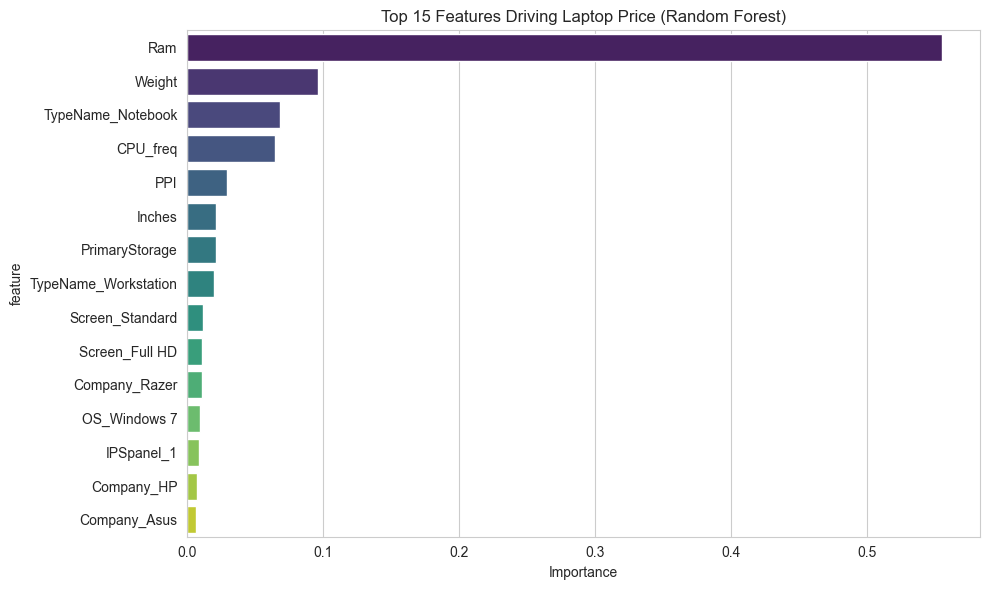

,feature,importance
1,Ram,0.555348
2,Weight,0.096165
27,TypeName_Notebook,0.067959
3,CPU_freq,0.064257
6,PPI,0.029449
0,Inches,0.021495
4,PrimaryStorage,0.021490
29,TypeName_Workstation,0.019597
40,Screen_Standard,0.011732
38,Screen_Full HD,0.010591


In [20]:
importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Features Driving Laptop Price (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importance

**Observation:** RAM dominates feature importance, contributing ~55% to predictions. Weight, laptop type, CPU frequency, and PPI are the next strongest drivers. This is interpretable and matches real-world intuition — these are exactly what you'd expect to drive laptop prices.

## 6. Predicted vs Actual

A scatter plot of predicted prices vs actual prices. Points close to the red diagonal line = good predictions.

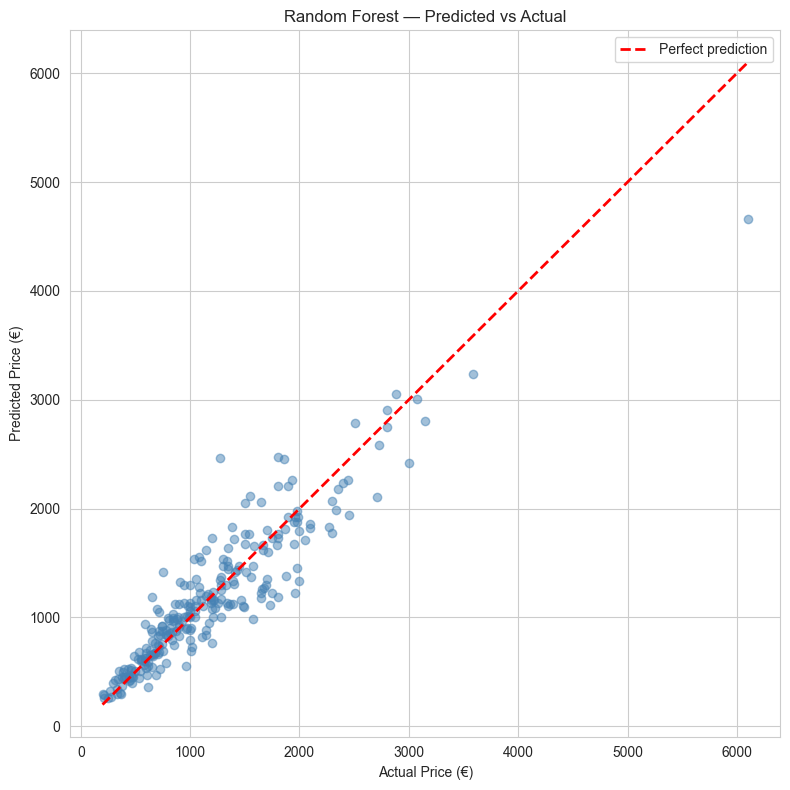

In [21]:
pred_rf = rf.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred_rf, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Price (€)')
plt.ylabel('Predicted Price (€)')
plt.title('Random Forest — Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Save the Trained Model

We save the Random Forest model and the feature columns so the Streamlit app (Day 3) can load them and make live predictions without retraining.

In [22]:
import joblib
import os

# Make sure the models folder exists
os.makedirs('../models', exist_ok=True)

# Save the trained model
joblib.dump(rf, '../models/random_forest_model.pkl')

# Save the feature columns list (the Streamlit app needs this to match column order)
joblib.dump(feature_columns, '../models/feature_columns.pkl')

print('✅ Model saved to ../models/random_forest_model.pkl')
print('✅ Feature columns saved to ../models/feature_columns.pkl')
print(f'\nModel file size: {os.path.getsize("../models/random_forest_model.pkl") / 1024 / 1024:.2f} MB')

✅ Model saved to ../models/random_forest_model.pkl
✅ Feature columns saved to ../models/feature_columns.pkl

Model file size: 16.65 MB


## 8. Conclusion

- **Random Forest clearly outperforms Linear Regression** (R² 0.85 vs 0.76, MAE €184 vs €252)
- **Most important features:** RAM, Weight, Laptop Type, CPU frequency, PPI
- The model handles non-linear relationships and feature interactions naturally
- Predictions are accurate within ~€184 on average, which is reasonable for the €174–€6,099 price range

**Next step:** Build a Streamlit app that loads this saved model and lets users predict laptop prices interactively (Day 3).